# Nutrition prompt lab

Profiling and accuracy analysis for the prompt Tally sends when someone logs a meal by text.

The harness mirrors the app's request path — same system prompt, same JSON Schema, same
per-provider quirks, same lenient decoding and the same bounds on what it is willing to believe.
So a number measured here is a number the app would have got. `Experiments/README.md` covers
the layout; `tally_eval/__init__.py` names the seams.

**Before running anything:**

1. `uv sync` in `Experiments/`, then launch with `uv run jupyter lab` — see the README
2. `cp ../.env.example ../.env` and fill in keys for the providers you want to measure
3. optionally `cp ../pricing.example.json ../pricing.json` and fill it, for cost columns

Every reply is cached on disk, so re-running a cell after editing one prompt only pays for that
prompt. `clear_cache()` when you want fresh numbers.

In [23]:
import sys
from pathlib import Path

EXPERIMENTS = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(EXPERIMENTS))

from dotenv import load_dotenv
load_dotenv(EXPERIMENTS / ".env")

import pandas as pd
import matplotlib.pyplot as plt

from tally_eval import analysis, viz
from tally_eval.dataset import load_dataset
from tally_eval.prompts import available_prompts, load_prompt, user_instruction
from tally_eval.providers import PROVIDERS
from tally_eval.runner import RunConfig, clear_cache, run_grid_async, save_runs

viz.use_style()
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 200)

# Which providers you can actually reach right now. Anything without a key is skipped rather
# than failing four hundred calls in.
ready = {name: bool(provider.api_key()) for name, provider in PROVIDERS.items()}
print("keys present:", ", ".join(name for name, ok in ready.items() if ok) or "none")
print("prompts:", ", ".join(available_prompts()))

keys present: anthropic, openai
prompts: shipped, draft, portion_anchored, terse


## 1. The prompt under test

`shipped.md` is generated from `Sources/TallyCore/LLM/ParsePrompt.swift`, so the baseline is the
text the app actually sends rather than a copy that was true once. Re-run
`python -m tally_eval.sync_prompt` after touching the Swift; `tests/test_offline.py` fails if you
forget.

In [24]:
baseline = load_prompt("shipped")
print(baseline.system)

You convert short descriptions of food and exercise into structured data for a calorie tracker. The user is logging what they ate or did, in their own words.

Return one item per thing the user would want to edit separately. "Eggs, toast and coffee" is three items; a composed dish like "chicken burrito bowl" is one. Every item is corrected on its own afterwards, so split the description across the items rather than repeating it: see `sourceText`.

Portions: when no quantity is given, assume one typical adult serving and say what you assumed in `note`. Prefer a decisive estimate to a hedge — every number here is editable, but a refusal is not useful to anyone.

For food, set `kind` to "food", `exerciseKind` to "none" and `durationMinutes` to 0. Give `calories`, `proteinGrams` and `fiberGrams` for the whole portion described, not per 100g.

For exercise, set `kind` to "exercise", `calories` to the energy burned as a positive number, `proteinGrams` and `fiberGrams` to 0, and `exerciseKind

In [25]:
# What each variant costs in prompt size. The system prompt is marked cacheable and identical on
# every request, so this is a much smaller lever than it looks — worth knowing, not worth
# optimising for on its own.
pd.DataFrame(
    [
        {
            "prompt": name,
            "chars": len(p.system),
            "words": len(p.system.split()),
            "vs baseline": f"{len(p.system) / len(baseline.system):.0%}",
            "notes": p.notes.split("\n")[0][:80],
        }
        for name in available_prompts()
        for p in [load_prompt(name)]
    ]
).set_index("prompt")

,chars,words,vs baseline,notes
prompt,,,,
shipped,2321,387,100%,
draft,2380,396,103%,
portion_anchored,3148,545,136%,"The shipped prompt plus four things, each aimed at a failure this ..."
terse,899,144,39%,"Roughly a third of the shipped prompt's length, keeping every rule..."


## 2. The known entries

Reference values are seed estimates, deliberately banded rather than exact — there is no true
calorie count for a bowl of chili, only a range a reasonable person accepts. Where you disagree
with one, edit `datasets/known_entries.jsonl` and every result here follows.

The `tags` column is what you slice by: `adversarial` and `empty` cases are the ones that catch
real damage, `splitting` is where prompt wording shows up most.

In [26]:
cases = load_dataset()

pd.DataFrame(
    [
        {
            "id": c.id,
            "text": c.text,
            "items": len(c.expected_items),
            "expected kcal": sum(i.calories for i in c.expected_items if i.calories) or None,
            "weight lb": c.body_weight_lb,
            "tags": ", ".join(c.tags),
        }
        for c in cases
    ]
).set_index("id")

,text,items,expected kcal,weight lb,tags
id,,,,,
eggs-toast-coffee,"Two eggs, sourdough toast with butter and a black coffee",3,318.0,NaN,"splitting, multi-item, breakfast"
burger-fries-shake,"cheeseburger, fries and a chocolate milkshake",3,1380.0,NaN,"splitting, multi-item"
chicken-burrito-bowl,chicken burrito bowl,1,700.0,NaN,"composed-dish, one-item, no-portion"
banana,a banana,1,105.0,NaN,"single-item, no-portion"
chicken-breast-8oz,8 oz grilled chicken breast,1,375.0,NaN,"explicit-portion, macros"
rice-150g,150 g of cooked white rice,1,195.0,NaN,"explicit-portion, metric"
almonds-200g,200 g of almonds,1,1160.0,NaN,"explicit-portion, per-100g-trap, adversarial"
big-mac-fries,Big Mac and medium fries,2,883.0,NaN,"branded, multi-item"
pizza-three-slices,three slices of pepperoni pizza,1,900.0,NaN,"explicit-portion, multiplier"


## 3. Smoke test — one call, fully visible

Run this first. It shows the exact request the app would send and everything that comes back,
which is the fastest way to catch a wrong key, a retired model identifier, or a provider that
has quietly changed its error shape.

In [27]:
SMOKE_CONFIG = RunConfig(provider="anthropic", model="claude-opus-5", effort="low")

case = next(c for c in cases if c.id == "eggs-toast-coffee")
print("system prompt:", len(baseline.system), "chars")
print("user turn:")
print(user_instruction(case.text, case.body_weight_lb))

system prompt: 2321 chars
user turn:
Log this: Two eggs, sourdough toast with butter and a black coffee


In [28]:
runs = await run_grid_async([case], [SMOKE_CONFIG], ["shipped"], progress=False)
run = runs[0]

print(f"{run.config}  ok={run.ok}  {run.latency_s:.2f}s  "
      f"{run.input_tokens} in / {run.output_tokens} out  cached={run.cached}")
if not run.ok:
    print("error:", run.error_kind, run.error_message)
print()
print(run.reply_text)

claude-opus-5 (low)  ok=True  6.18s  29 in / 103 out  cached=True

{"items":[{"calories":0,"confidence":"high","durationMinutes":0,"exerciseKind":"none","fiberGrams":0,"kind":"food","label":"Two eggs","proteinGrams":12,"sourceText":"Two eggs?  null}"}],"note":""}


In [29]:
# The same reply after the app's own decoding: bounds enforced, unusable items dropped.
analysis.replies_for(runs, case.id)

,prompt,config,repeat,label,kind,calories,protein_g,fiber_g,duration_min,confidence,source_text
0,shipped,claude-opus-5 (low),0,Two eggs,food,0,12.0,0.0,None,high,Two eggs? null}


## 4. The grid

One row per prompt, one column per model. Start small — two prompts and two models over thirty
cases is 120 calls — and widen once you know the shape.

`repeats` matters more than it looks. These models are not deterministic, and a one-shot
comparison of two prompts is mostly noise; three repeats is usually enough to tell a real
difference from a coin flip.

In [30]:
CONFIGS = [
    # RunConfig(provider="anthropic", model="claude-opus-5", effort="low"),
    # RunConfig(provider="anthropic", model="claude-sonnet-5", effort="low"),
    # RunConfig(provider="anthropic", model="claude-haiku-4-5"),
    # Add your own. Effort is dropped automatically for models that reject it, so a config that
    # names one is safe either way.
    RunConfig(provider="openai", model="gpt-5.6-luna", effort="low"),
    RunConfig(provider="openai", model="gpt-5.6-luna", effort="medium"),
    RunConfig(provider="openai", model="gpt-5.6-luna", effort="high"),
    # RunConfig(provider="deepseek", model="deepseek-chat"),
]
PROMPTS = ["shipped", "terse", "portion_anchored"]
REPEATS = 3

CONFIGS = [c for c in CONFIGS if ready.get(c.provider)]
print(f"{len(PROMPTS)} prompts x {len(CONFIGS)} configs x {len(cases)} cases x {REPEATS} repeats "
      f"= {len(PROMPTS) * len(CONFIGS) * len(cases) * REPEATS} calls")

3 prompts x 3 configs x 28 cases x 3 repeats = 756 calls


In [31]:
runs = await run_grid_async(cases, CONFIGS, PROMPTS, repeats=REPEATS, concurrency=8)

756/756 calls  (203s)
756 results, 756 live calls, 0 from cache.


## 5. Accuracy

`total_in_band_rate` is the headline: did the day's total land inside the reference band? It is
the metric most robust to a defensible difference of opinion — a model that returns "oatmeal
with blueberries and honey" as one item and a model that returns three are both right, and both
should total the same.

The rest earn their place by disagreeing with it:

- `usable_rate` — the reply decoded and produced items. Below 1.0 means the user saw an error.
- `item_f1` — were the individual things identified and split as the prompt asks?
- `source_text_ok_rate` — did each item carry the user's own words for *that item alone*?
- `dropped_items` — items the app would silently discard. Should be zero on a schema-enforcing
  provider; anything else is a real finding.

In [32]:
summary = analysis.summary_frame(runs, cases)
summary[[
    "usable_rate", "total_in_band_rate", "total_mape", "item_f1",
    "calories_ok_rate", "source_text_ok_rate", "dropped_items", "transport_failures",
]].style.format({
    "usable_rate": "{:.0%}", "total_in_band_rate": "{:.0%}", "total_mape": "{:.1%}",
    "item_f1": "{:.2f}", "calories_ok_rate": "{:.0%}", "source_text_ok_rate": "{:.0%}",
}, na_rep="—").background_gradient(subset=["total_in_band_rate"], cmap="Blues", vmin=0, vmax=1)

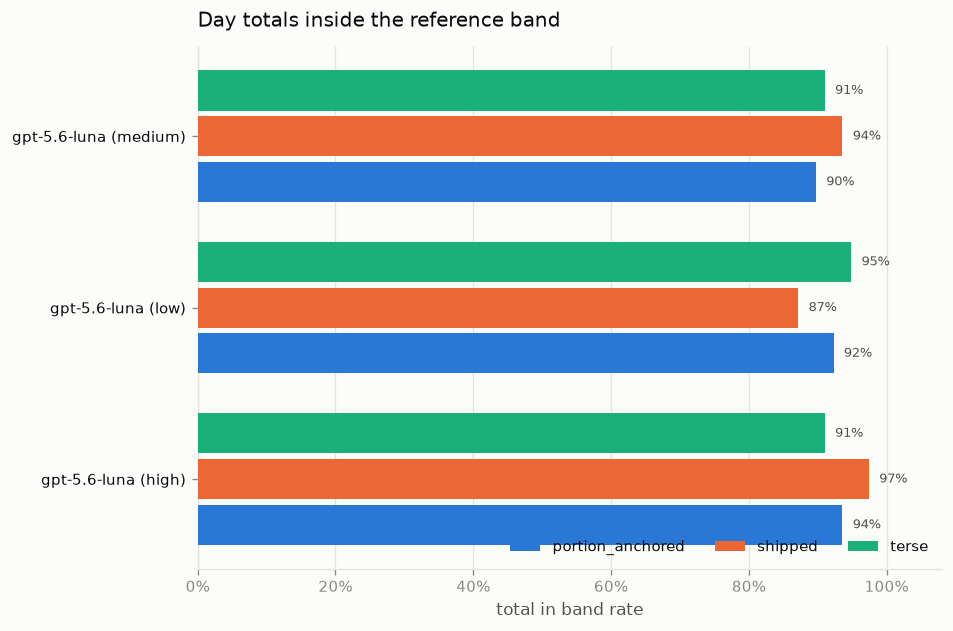

In [33]:
viz.accuracy_chart(summary)
plt.show()

### Accuracy by tag

Where a prompt change actually landed. A variant that lifts the headline by two points while
halving `adversarial` is not an improvement — it has learned to guess.

In [34]:
scores = analysis.scores_frame(runs, cases)
by_tag = (
    scores.assign(tag=scores["tags"].str.split(","))
    .explode("tag")
    .query("tag != ''")
    .groupby(["prompt", "tag"])["total_in_band"]
    .mean()
    .unstack("prompt")
)
by_tag.style.format("{:.0%}", na_rep="—").background_gradient(cmap="Blues", vmin=0, vmax=1)

prompt,portion_anchored,shipped,terse
tag,,,
adversarial,100%,100%,100%
ambiguous,100%,100%,100%
assumption,100%,100%,100%
branded,100%,100%,100%
breakfast,100%,100%,100%
composed-dish,100%,86%,97%
distance,100%,100%,100%
drink,94%,94%,94%
duration,94%,89%,92%


## 6. Profiling

Latency is the number a user standing in their kitchen actually experiences, so it is measured
around the HTTP round trip and nothing else. p95 matters more than the median here: the app
shows a spinner, and the occasional slow call is what people remember.

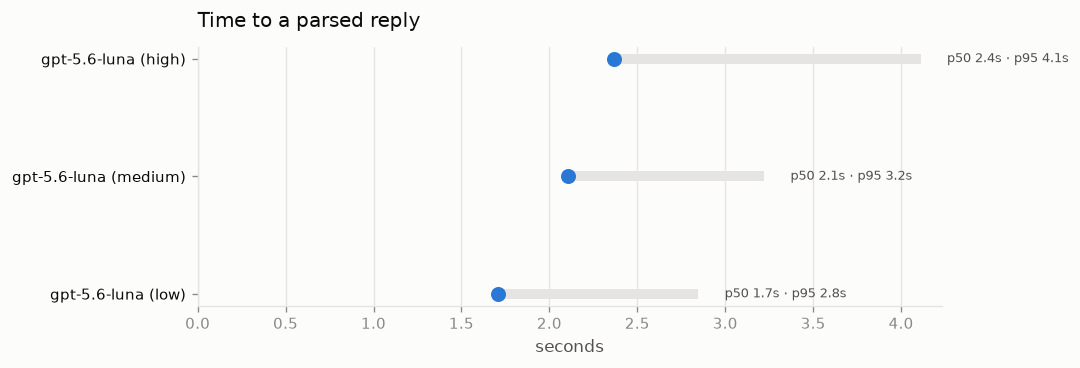

In [35]:
frame = analysis.runs_frame(runs)
live = frame[~frame["cached"]]
if live.empty:
    print("Every result came from cache — latency below is from the run that populated it.")
viz.latency_chart(frame)
plt.show()

In [36]:
summary[["p50_latency_s", "p95_latency_s", "mean_output_tokens", "cost_per_call_usd", "calls"]].style.format({
    "p50_latency_s": "{:.2f}s", "p95_latency_s": "{:.2f}s",
    "mean_output_tokens": "{:.0f}", "cost_per_call_usd": "${:.5f}",
}, na_rep="—")

`cost_per_call_usd` is blank until you fill `pricing.json` — see `pricing.example.json`. Blank
means unknown, not free: list prices move often enough that a table baked into the repository
would be a source of confidently wrong numbers.

## 7. Where it goes wrong

The summary tells you A beat B. This tells you *how* — which is what you actually edit a prompt
against.

In [37]:
problems = analysis.failures(runs, cases)
print(f"{len(problems)} problem rows out of {len(runs)} calls")
problems.groupby(["prompt", "config"]).size().unstack("prompt").fillna(0).astype(int)

58 problem rows out of 756 calls


prompt,portion_anchored,shipped,terse
config,,,
gpt-5.6-luna (high),5,3,7
gpt-5.6-luna (low),8,10,4
gpt-5.6-luna (medium),8,6,7


In [38]:
# The individual failures. Widen `limit` or filter by prompt to read them all.
problems[problems["prompt"] == "shipped"][["config", "case_id", "text", "problem"]].head(25)

,config,case_id,text,problem
0,gpt-5.6-luna (low),apple-peanut-butter,apple with two tablespoons of peanut butter,total 580 vs 285 (+104%)
1,gpt-5.6-luna (low),apple-peanut-butter,apple with two tablespoons of peanut butter,total 475 vs 285 (+67%)
2,gpt-5.6-luna (low),apple-peanut-butter,apple with two tablespoons of peanut butter,total 475 vs 285 (+67%)
3,gpt-5.6-luna (low),oatmeal-blueberries-honey,a bowl of oatmeal with blueberries and honey,total 350 vs 254 (+38%)
4,gpt-5.6-luna (low),oatmeal-blueberries-honey,a bowl of oatmeal with blueberries and honey,total 350 vs 254 (+38%)
5,gpt-5.6-luna (low),salmon-nigiri,8 pieces of salmon nigiri,total 480 vs 340 (+41%)
6,gpt-5.6-luna (low),salmon-nigiri,8 pieces of salmon nigiri,total 472 vs 340 (+39%)
7,gpt-5.6-luna (low),salmon-nigiri,8 pieces of salmon nigiri,total 480 vs 340 (+41%)
8,gpt-5.6-luna (low),weights-45min,45 minutes of lifting weights,total 370 vs 230 (+61%)
9,gpt-5.6-luna (low),weights-45min,45 minutes of lifting weights,total 360 vs 230 (+57%)


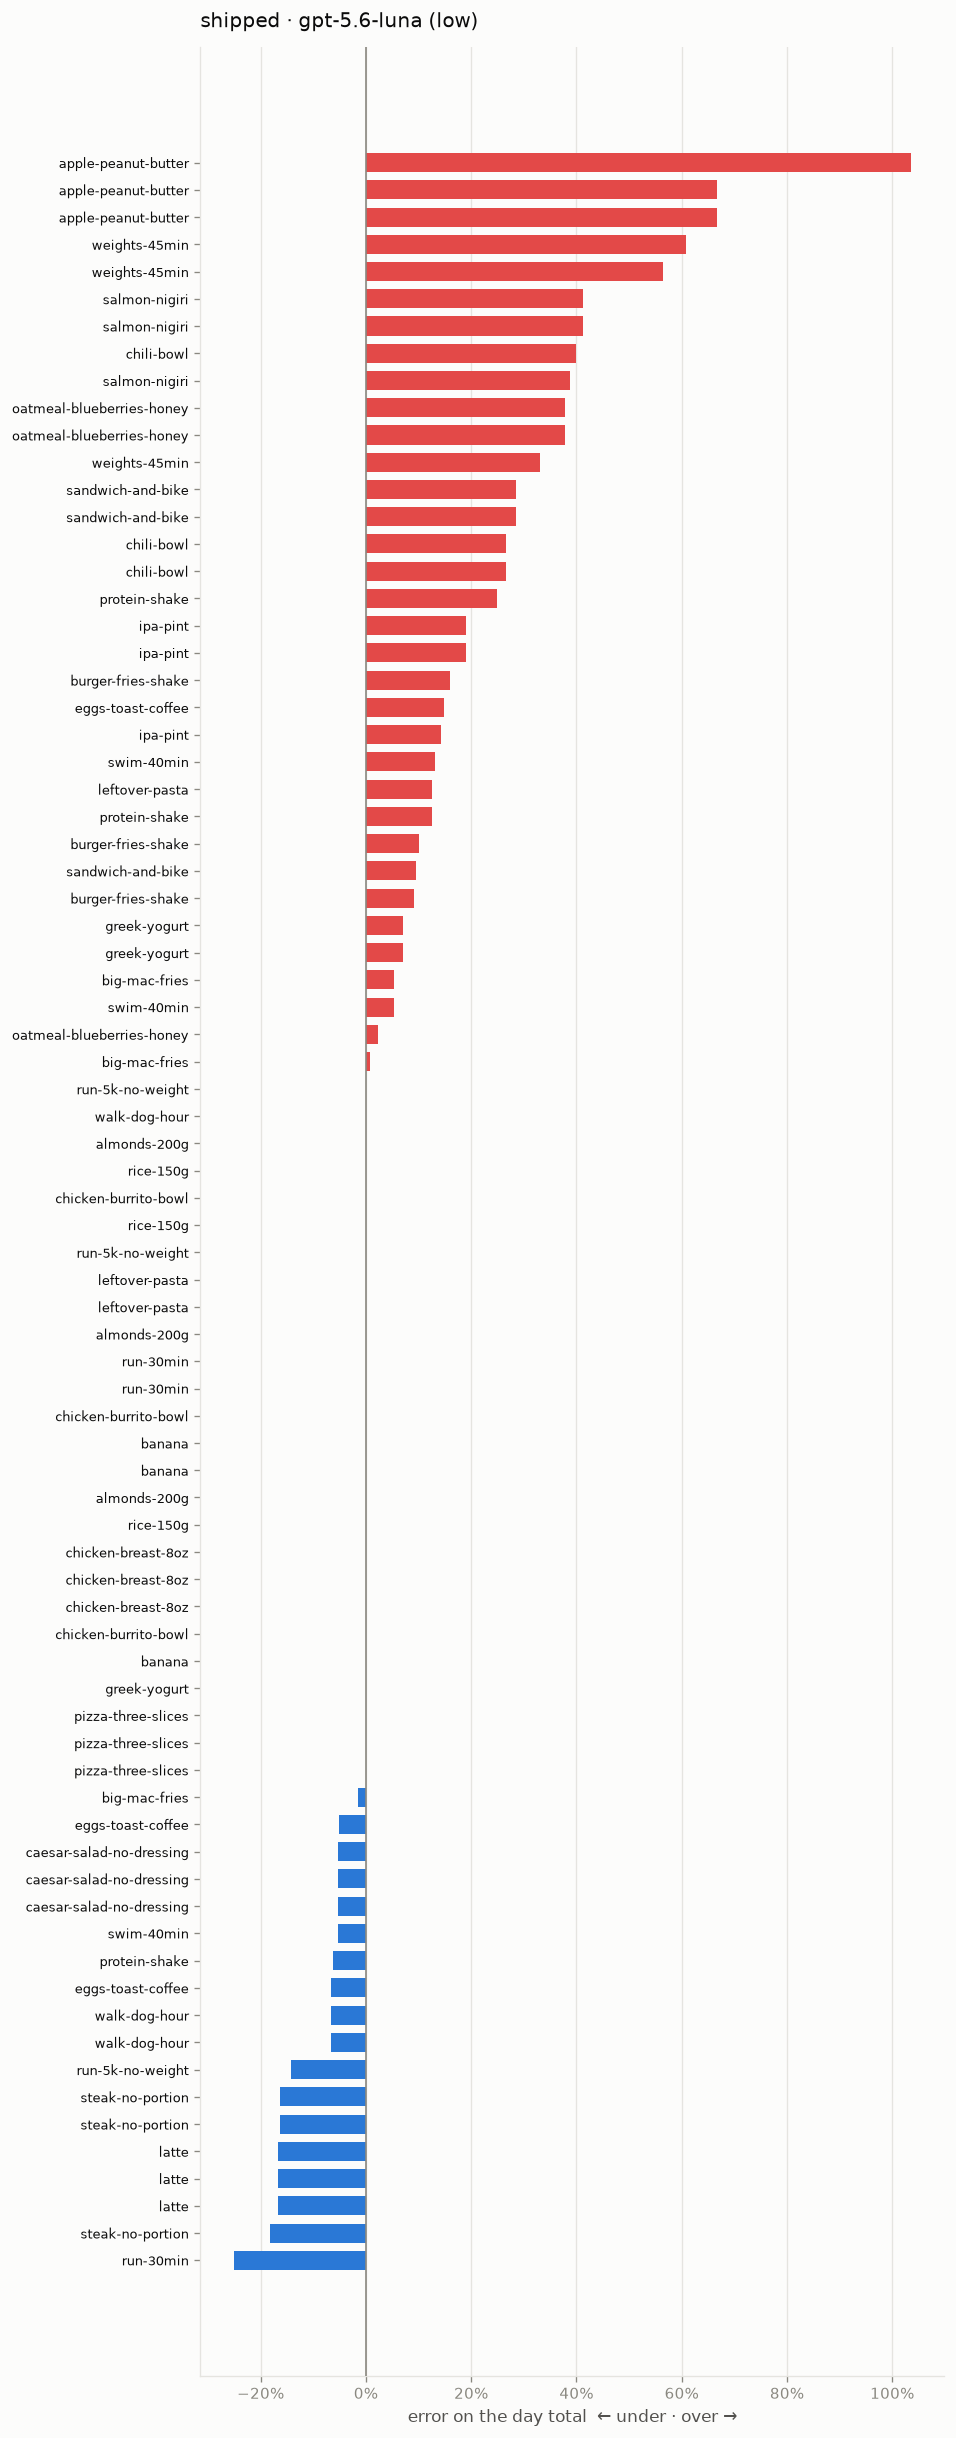

In [39]:
# Signed error per case for one cell. Under-counting is the more damaging direction: a tracker
# that reads low every day tells someone they can eat more.
viz.error_chart(scores, config=CONFIGS[0].name, prompt="shipped")
plt.show()

### Drill into one case

When the aggregate says two prompts differ, this is where you see what that looked like.

In [40]:
analysis.replies_for(runs, "almonds-200g")

,prompt,config,repeat,label,kind,calories,protein_g,fiber_g,duration_min,confidence,source_text
0,shipped,gpt-5.6-luna (low),0,200 g almonds,food,1160,42.4,25.0,None,high,200 g of almonds
1,shipped,gpt-5.6-luna (low),1,Almonds,food,1160,42.0,25.0,None,high,200 g of almonds
2,shipped,gpt-5.6-luna (low),2,Almonds,food,1160,42.0,25.0,None,high,200 g of almonds
3,shipped,gpt-5.6-luna (medium),0,Almonds,food,1158,42.4,25.0,None,high,200 g of almonds
4,shipped,gpt-5.6-luna (medium),1,Almonds,food,1158,42.4,25.2,None,high,200 g of almonds
5,shipped,gpt-5.6-luna (medium),2,Almonds,food,1158,42.4,25.0,None,high,200 g of almonds
6,shipped,gpt-5.6-luna (high),0,Almonds,food,1158,42.4,25.0,None,high,200 g of almonds
7,shipped,gpt-5.6-luna (high),1,Almonds,food,1158,42.4,25.0,None,high,200 g of almonds
8,shipped,gpt-5.6-luna (high),2,Almonds,food,1158,42.4,25.0,None,high,200 g of almonds
9,terse,gpt-5.6-luna (low),0,Almonds,food,1158,42.4,25.2,None,high,200 g of almonds


## 8. The tweaking loop

Write a variant, run it against one model over the cases it is meant to fix, and only widen the
grid once it looks worth the calls. Prompts are files, so a variant that survives is something
you can diff and fold back into `ParsePrompt.swift`.

In [41]:
from tally_eval.prompts import PROMPTS_DIR, load_prompt

DRAFT = "draft"
variant = baseline.system.replace(
    "Prefer a decisive estimate to a hedge",
    "State the portion you assumed in `note` before estimating. Prefer a decisive estimate to a hedge",
)
(PROMPTS_DIR / f"{DRAFT}.md").write_text(variant, encoding="utf-8")

load_prompt.cache_clear()  # prompts are cached per name; a rewritten file needs the reload
print(f"wrote {DRAFT}.md — {len(variant)} chars")

wrote draft.md — 2380 chars


In [42]:
focus = [c for c in cases if "no-portion" in c.tags or "assumption" in c.tags]
draft_runs = await run_grid_async(focus, CONFIGS[:1], ["shipped", DRAFT], repeats=REPEATS)

analysis.summary_frame(draft_runs, focus)[
    ["usable_rate", "total_in_band_rate", "total_mape", "p50_latency_s"]
].style.format({
    "usable_rate": "{:.0%}", "total_in_band_rate": "{:.0%}",
    "total_mape": "{:.1%}", "p50_latency_s": "{:.2f}s",
}, na_rep="—")

42/42 calls  (5s)
42 results, 21 live calls, 21 from cache.


## 9. Keeping a result

Runs are saved as JSONL so a result from last week can be reloaded and compared against today's
— which is the only way to tell a prompt improvement from a change at the provider's end.

In [43]:
from datetime import datetime

stamp = datetime.now().strftime("%Y%m%d-%H%M")
path = save_runs(runs, EXPERIMENTS / "results" / f"run-{stamp}.jsonl")
summary.to_csv(EXPERIMENTS / "results" / f"summary-{stamp}.csv")
print("saved", path.name)

saved run-20260802-2132.jsonl


In [44]:
# Fresh numbers on the next run, at full price.
# clear_cache()